# Apresentação do Eixo 1 
## Grupo:
- ### Leonardo D.
- ### João Pedro M.
- ### Thiago T.
- ### Victor B.
- ### Julio Cesar A. 

In [ ]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from dython.nominal import associations

## **Verificações iniciais dos dados**

In [201]:
df = pd.read_csv("data/bmw.csv")
display(df)

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,5 Series,2014,11200,Automatic,67068,Diesel,125,57.6,2.0
1,6 Series,2018,27000,Automatic,14827,Petrol,145,42.8,2.0
2,5 Series,2016,16000,Automatic,62794,Diesel,160,51.4,3.0
3,1 Series,2017,12750,Automatic,26676,Diesel,145,72.4,1.5
4,7 Series,2014,14500,Automatic,39554,Diesel,160,50.4,3.0
...,...,...,...,...,...,...,...,...,...
10776,X3,2016,19000,Automatic,40818,Diesel,150,54.3,2.0
10777,5 Series,2016,14600,Automatic,42947,Diesel,125,60.1,2.0
10778,3 Series,2017,13100,Manual,25468,Petrol,200,42.8,2.0
10779,1 Series,2014,9930,Automatic,45000,Diesel,30,64.2,2.0


### **Renomeando colunas para facilitar o entendimento**

In [202]:
map = {
    'model': 'modelo',
    'year': 'ano',
    'price': 'preço',
    'transmission': 'transmissão',
    'mileage': 'quilometragem',
    'fuelType': 'tipo de combustivel',
    'tax': 'imposto',
    'mpg': 'economia', 
    'engineSize': 'cilindradas'
}

df.rename(columns=map, inplace=True)

# Corrige espaços errados na coluna do nome
df['modelo'] = df['modelo'].str.strip()

display(df)

,modelo,ano,preço,transmissão,quilometragem,tipo de combustivel,imposto,economia,cilindradas
0,5 Series,2014,11200,Automatic,67068,Diesel,125,57.6,2.0
1,6 Series,2018,27000,Automatic,14827,Petrol,145,42.8,2.0
2,5 Series,2016,16000,Automatic,62794,Diesel,160,51.4,3.0
3,1 Series,2017,12750,Automatic,26676,Diesel,145,72.4,1.5
4,7 Series,2014,14500,Automatic,39554,Diesel,160,50.4,3.0
...,...,...,...,...,...,...,...,...,...
10776,X3,2016,19000,Automatic,40818,Diesel,150,54.3,2.0
10777,5 Series,2016,14600,Automatic,42947,Diesel,125,60.1,2.0
10778,3 Series,2017,13100,Manual,25468,Petrol,200,42.8,2.0
10779,1 Series,2014,9930,Automatic,45000,Diesel,30,64.2,2.0


### **Verificação de dados faltantes**

In [203]:
print(df.isnull().sum())

modelo                 0
ano                    0
preço                  0
transmissão            0
quilometragem          0
tipo de combustivel    0
imposto                0
economia               0
cilindradas            0
dtype: int64


### **Verificação dos modelos**

In [204]:
print(f"Modelos distintos nos dados: {df["modelo"].nunique()}")
print("\n----------------------------------------------------------------\n")
print(f"Quais são esses modelos: {df["modelo"].unique()}")
print("\n----------------------------------------------------------------\n")
print(f"Quantas vezes cada modelo aparece:\n{df["modelo"].value_counts()}")

Modelos distintos nos dados: 24

----------------------------------------------------------------

Quais são esses modelos: <StringArray>
['5 Series', '6 Series', '1 Series', '7 Series', '2 Series', '4 Series',
       'X3', '3 Series',       'X5',       'X4',       'i3',       'X1',
       'M4',       'X2',       'X6', '8 Series',       'Z4',       'X7',
       'M5',       'i8',       'M2',       'M3',       'M6',       'Z3']
Length: 24, dtype: str

----------------------------------------------------------------

Quantas vezes cada modelo aparece:
modelo
3 Series    2443
1 Series    1969
2 Series    1229
5 Series    1056
4 Series     995
X1           804
X3           551
X5           468
X2           288
X4           179
M4           125
6 Series     108
Z4           108
7 Series     106
X6           106
X7            55
i3            43
8 Series      39
M5            29
M3            27
M2            21
i8            17
M6             8
Z3             7
Name: count, dtype: int64


### Reparamos que nossos dados estão divididos entre **modelos e séries** (uma série agrupa vários modelos). Por isso, decidimos separar os dados em um **dataframe de modelos apenas** e outro **dataframe de séries apenas**.

In [205]:
# Define o critério de seleção
mask = df["modelo"].str.contains("Series", na=False)

# Separando quem atende ao critério
df_series = df[mask].copy()

# Separando quem não atende ao critério
df_models = df[~mask].copy()

# Verificação
print(f"Total original: {len(df)}")
print(f"Séries: {len(df_series)}")
print(f"Modelos: {len(df_models)}")

Total original: 10781
Séries: 7945
Modelos: 2836


### Agora, com dois dataframes distintos, podemos analisá-los separadamente

## **Plots e gráficos**

### **Matriz de correlação**
Este conjunto de dados possui alguns atributos categóricos (modelo, ano, transmissão e tipo de combustível). Por isso, nós usamos uma abordagem diferente: a função `df.corr()` do pandas usa a correlação de **Pearson** por padrão, que mede a relação entre variáveis numéricas. Se nós apenas fizessemos encoding nos atributos categóricos (ex: BMW X1 = 1, BMW X3 = 2), o Pearson tentaria achar uma relação matemática falsa, achando que o X3 "vale o dobro" do X1, o que não faz sentido.

Para contornar, usamos o pacote `dython`, que possui a **Razão de Correlação** (Correlation Ratio), ou seja, mede o quanto a dispersão de um dado numérico é explicada por categorias. Também possui Cramér's V (para categóricos x categóricos) e Pearson (numéricos x numéricos).

#### **Matriz de correlação dos modelos:**

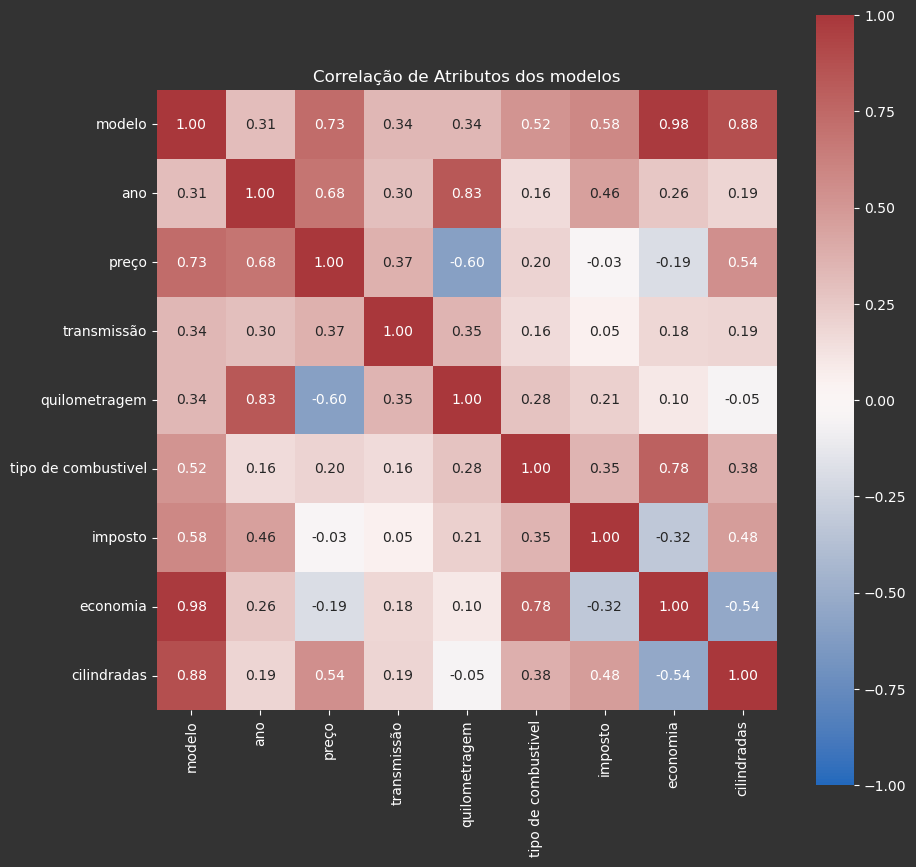

In [206]:
# Configurações visuais do Dark Mode
plt.style.use('dark_background')
plt.rcParams['figure.facecolor'] = '#333333'
plt.rcParams['axes.facecolor'] = '#444444'

# Colunas categóricas
categorical_columns = ['modelo', 'ano', 'transmissão', 'tipo de combustivel']

# A função já calcula e plota automaticamente
result= associations(
    df_models,
    nominal_columns=categorical_columns,
    compute_only=False, # Gera o gráfico
    cmap='vlag',    # Mapa de cores 
    figsize=(10, 10), 
    title="Correlação de Atributos dos modelos"
)

# Também recuperamos os valores numéricos
corr_matrix = result['corr']

**Para interpretar estes resultados, vamos dividir em 5 categorias:**
- 0.00 a 0.19 - Muito Fraca	
- 0.20 a 0.39 - Fraca: Existe uma leve tendência, mas com muito ruído
- 0.40 a 0.59 - Moderada: Uma variável começa a explicar a outra
- 0.60 a 0.79 - Forte: Relação confiável
- 0.80 a 1.00 - Muito Forte: As vezes é a mesma informação mapeada de formas diferentes

In [207]:
# Transforma em valores absolutos (valores muito
# negativos indicam correlação inversamente proporcional)
corr_abs = corr_matrix.abs()

# Máscara para evitar repetição 
mask = np.triu(np.ones_like(corr_abs, dtype=bool), k=1)

# Transforma a matriz em uma lista de pares (coluna1, coluna2, valor)
corr_pairs = corr_abs.where(mask).stack().reset_index()
corr_pairs.columns = ['Feature_1', 'Feature_2', 'Correlation_Value']

# Define as fronteiras e os títulos
bins = [0.0, 0.20, 0.40, 0.60, 0.80, 1.0]
labels = ['Muito Fraco', 'Fraco', 'Moderado', 'Forte', 'Muito Forte']

# Aplica as fronteiras e títulos
corr_pairs['Strength'] = pd.cut(
    corr_pairs['Correlation_Value'], 
    bins=bins, 
    labels=labels, 
    include_lowest=True 
)

# Ordena os dados 
corr_pairs = corr_pairs.sort_values(by='Correlation_Value', ascending=False)

# Lista corrigida para usar as mesmas strings da variável 'labels' (ordem decrescente)
categories_to_print = ['Muito Forte', 'Forte', 'Moderado', 'Fraco', 'Muito Fraco']

for category in categories_to_print:
    print(f"\n=== CORRELAÇÃO {category.upper()} ===")
    
    # Filtra a categoria atual
    category_data = corr_pairs[corr_pairs['Strength'] == category]
    
    # Se a categoria não possui pares, deixa uma mensagem
    if category_data.empty:
        print("Não há pares nessa categoria.")
        continue
        
    for _, row in category_data.iterrows():
        feat1 = row['Feature_1']
        feat2 = row['Feature_2']
        val = row['Correlation_Value']
        print(f"[{val:.3f}] {feat1} <--> {feat2}")


=== CORRELAÇÃO MUITO FORTE ===
[0.980] modelo <--> economia
[0.879] modelo <--> cilindradas
[0.834] ano <--> quilometragem

=== CORRELAÇÃO FORTE ===
[0.782] tipo de combustivel <--> economia
[0.729] modelo <--> preço
[0.680] ano <--> preço
[0.601] preço <--> quilometragem

=== CORRELAÇÃO MODERADO ===
[0.580] modelo <--> imposto
[0.542] preço <--> cilindradas
[0.537] economia <--> cilindradas
[0.517] modelo <--> tipo de combustivel
[0.476] imposto <--> cilindradas
[0.455] ano <--> imposto

=== CORRELAÇÃO FRACO ===
[0.375] tipo de combustivel <--> cilindradas
[0.374] preço <--> transmissão
[0.355] transmissão <--> quilometragem
[0.353] tipo de combustivel <--> imposto
[0.342] modelo <--> quilometragem
[0.341] modelo <--> transmissão
[0.321] imposto <--> economia
[0.312] modelo <--> ano
[0.297] ano <--> transmissão
[0.281] quilometragem <--> tipo de combustivel
[0.259] ano <--> economia
[0.212] quilometragem <--> imposto

=== CORRELAÇÃO MUITO FRACO ===
[0.197] preço <--> tipo de combusti

**Insights interessantes:**
- Correlações muito fortes e fortes (preço e quilometragem são inversos);
- Correlações muito fracas (preço e imposto, quilometragem e economia)

#### **Matriz de correlação das séries**

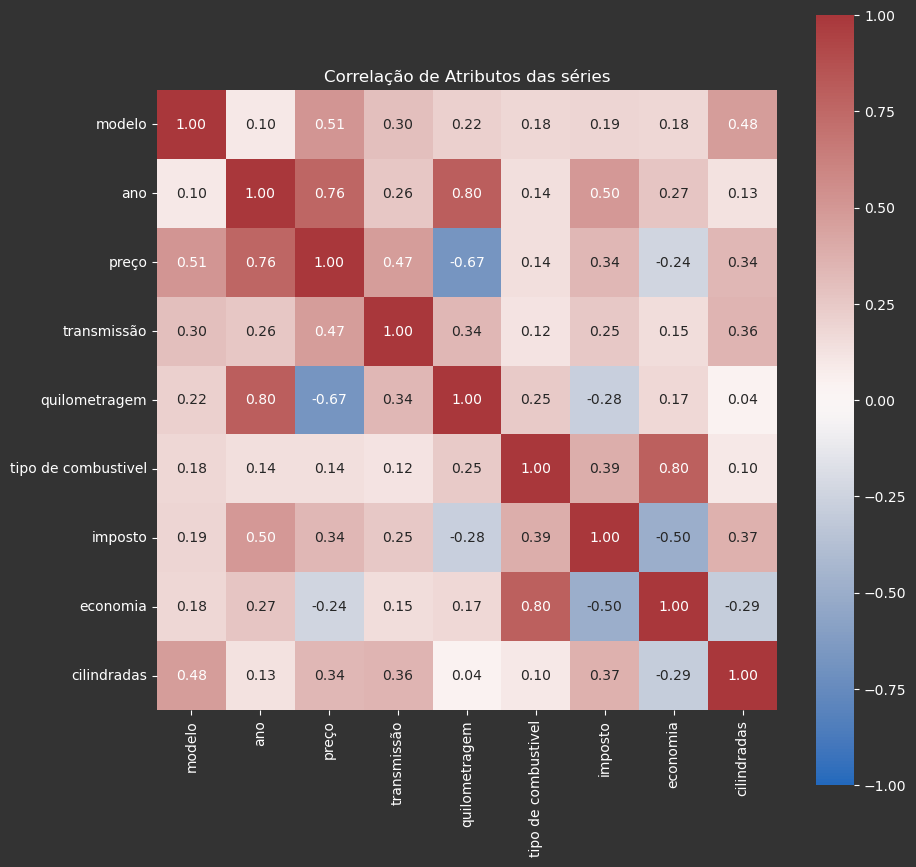


=== CORRELAÇÃO MUITO FORTE ===
[0.801] ano <--> quilometragem

=== CORRELAÇÃO FORTE ===
[0.795] tipo de combustivel <--> economia
[0.764] ano <--> preço
[0.672] preço <--> quilometragem

=== CORRELAÇÃO MODERADO ===
[0.511] modelo <--> preço
[0.500] imposto <--> economia
[0.499] ano <--> imposto
[0.475] modelo <--> cilindradas
[0.472] preço <--> transmissão

=== CORRELAÇÃO FRACO ===
[0.388] tipo de combustivel <--> imposto
[0.373] imposto <--> cilindradas
[0.359] transmissão <--> cilindradas
[0.343] preço <--> imposto
[0.341] preço <--> cilindradas
[0.336] transmissão <--> quilometragem
[0.298] modelo <--> transmissão
[0.294] economia <--> cilindradas
[0.277] quilometragem <--> imposto
[0.273] ano <--> economia
[0.265] ano <--> transmissão
[0.254] transmissão <--> imposto
[0.248] quilometragem <--> tipo de combustivel
[0.241] preço <--> economia
[0.218] modelo <--> quilometragem

=== CORRELAÇÃO MUITO FRACO ===
[0.195] modelo <--> imposto
[0.184] modelo <--> economia
[0.183] modelo <-->

In [208]:
# Colunas categóricas
categorical_columns = ['modelo', 'ano', 'transmissão', 'tipo de combustivel']

# A função já calcula e plota automaticamente
result= associations(
    df_series,
    nominal_columns=categorical_columns,
    compute_only=False, # Gera o gráfico
    cmap='vlag',    # Mapa de cores 
    figsize=(10, 10), 
    title="Correlação de Atributos das séries"
)

# Também recuperamos os valores numéricos
corr_matrix = result['corr']

# Transforma em valores absolutos (valores muito
# negativos indicam correlação inversamente proporcional)
corr_abs = corr_matrix.abs()

# Máscara para evitar repetição 
mask = np.triu(np.ones_like(corr_abs, dtype=bool), k=1)

# Transforma a matriz em uma lista de pares (coluna1, coluna2, valor)
corr_pairs = corr_abs.where(mask).stack().reset_index()
corr_pairs.columns = ['Feature_1', 'Feature_2', 'Correlation_Value']

# Define as fronteiras e os títulos
bins = [0.0, 0.20, 0.40, 0.60, 0.80, 1.0]
labels = ['Muito Fraco', 'Fraco', 'Moderado', 'Forte', 'Muito Forte']

# Aplica as fronteiras e títulos
corr_pairs['Strength'] = pd.cut(
    corr_pairs['Correlation_Value'], 
    bins=bins, 
    labels=labels, 
    include_lowest=True 
)

# Ordena os dados 
corr_pairs = corr_pairs.sort_values(by='Correlation_Value', ascending=False)

# Lista corrigida para usar as mesmas strings da variável 'labels' (ordem decrescente)
categories_to_print = ['Muito Forte', 'Forte', 'Moderado', 'Fraco', 'Muito Fraco']

for category in categories_to_print:
    print(f"\n=== CORRELAÇÃO {category.upper()} ===")
    
    # Filtra a categoria atual
    category_data = corr_pairs[corr_pairs['Strength'] == category]
    
    # Se a categoria não possui pares, deixa uma mensagem
    if category_data.empty:
        print("Não há pares nessa categoria.")
        continue
        
    for _, row in category_data.iterrows():
        feat1 = row['Feature_1']
        feat2 = row['Feature_2']
        val = row['Correlation_Value']
        print(f"[{val:.3f}] {feat1} <--> {feat2}")

### **Boxplots:**

#### **Gráficos de caixa dos modelos**

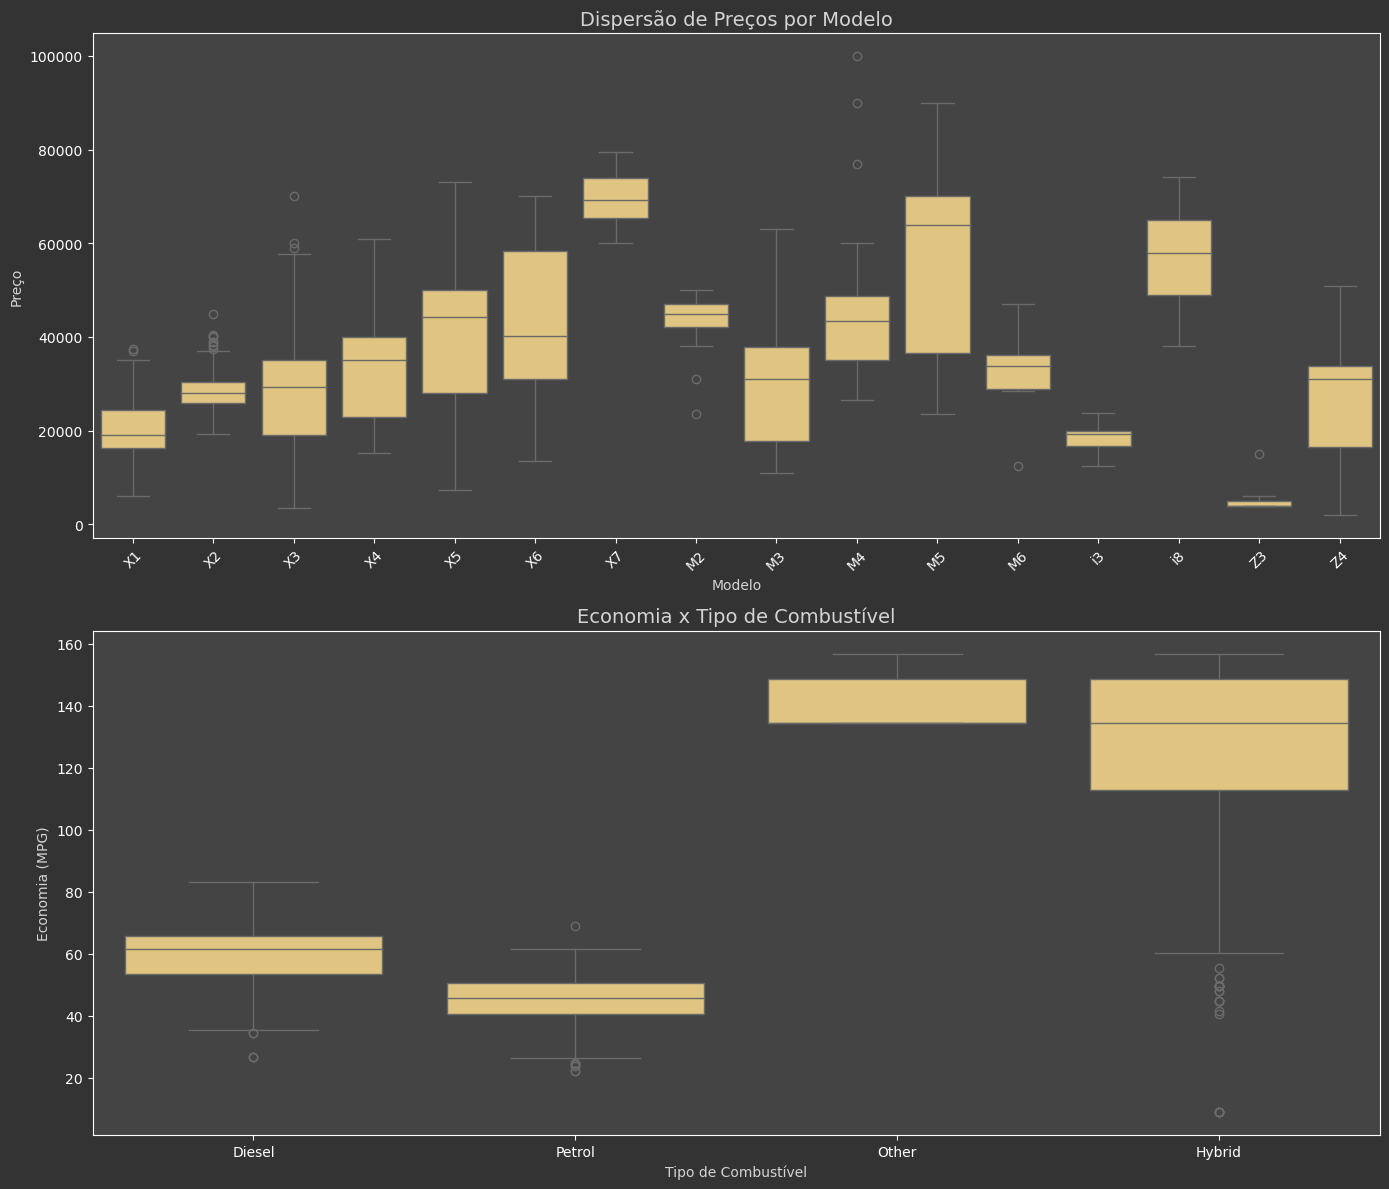

In [209]:
# Cria uma figura com espaço pra 2 gráficos
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(14, 12))

# Define a ordem 
model_order = [
    'X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 
    'M2', 'M3', 'M4', 'M5', 'M6', 
    'i3', 'i8', 
    'Z3', 'Z4'
]

# Preço x Modelo
sns.boxplot(
    data=df_models,
    x='modelo',
    y='preço',
    order=model_order,
    color="#f0ca71",
    ax=axes[0]
)
axes[0].set_title('Dispersão de Preços por Modelo', color='#D4D4D4', fontsize=14)
axes[0].set_ylabel('Preço', color='#d4d4d4')
axes[0].set_xlabel('Modelo', color='#d4d4d4')

# Rotaciona os nomes dos modelos em 45 
axes[0].tick_params(axis='x', rotation=45) 

# Economia x Combustível 
sns.boxplot(
    data=df_series,
    x='tipo de combustivel',
    y='economia',
    color="#f0ca71",
    ax=axes[1]
)
axes[1].set_title('Economia x Tipo de Combustível', color='#d4d4d4', fontsize=14)
axes[1].set_ylabel('Economia (MPG)', color='#d4d4d4')
axes[1].set_xlabel('Tipo de Combustível', color='#d4d4d4')

# Ajusta o espaçamento
plt.tight_layout()
plt.show()

#### **Gráficos de caixa das séries**

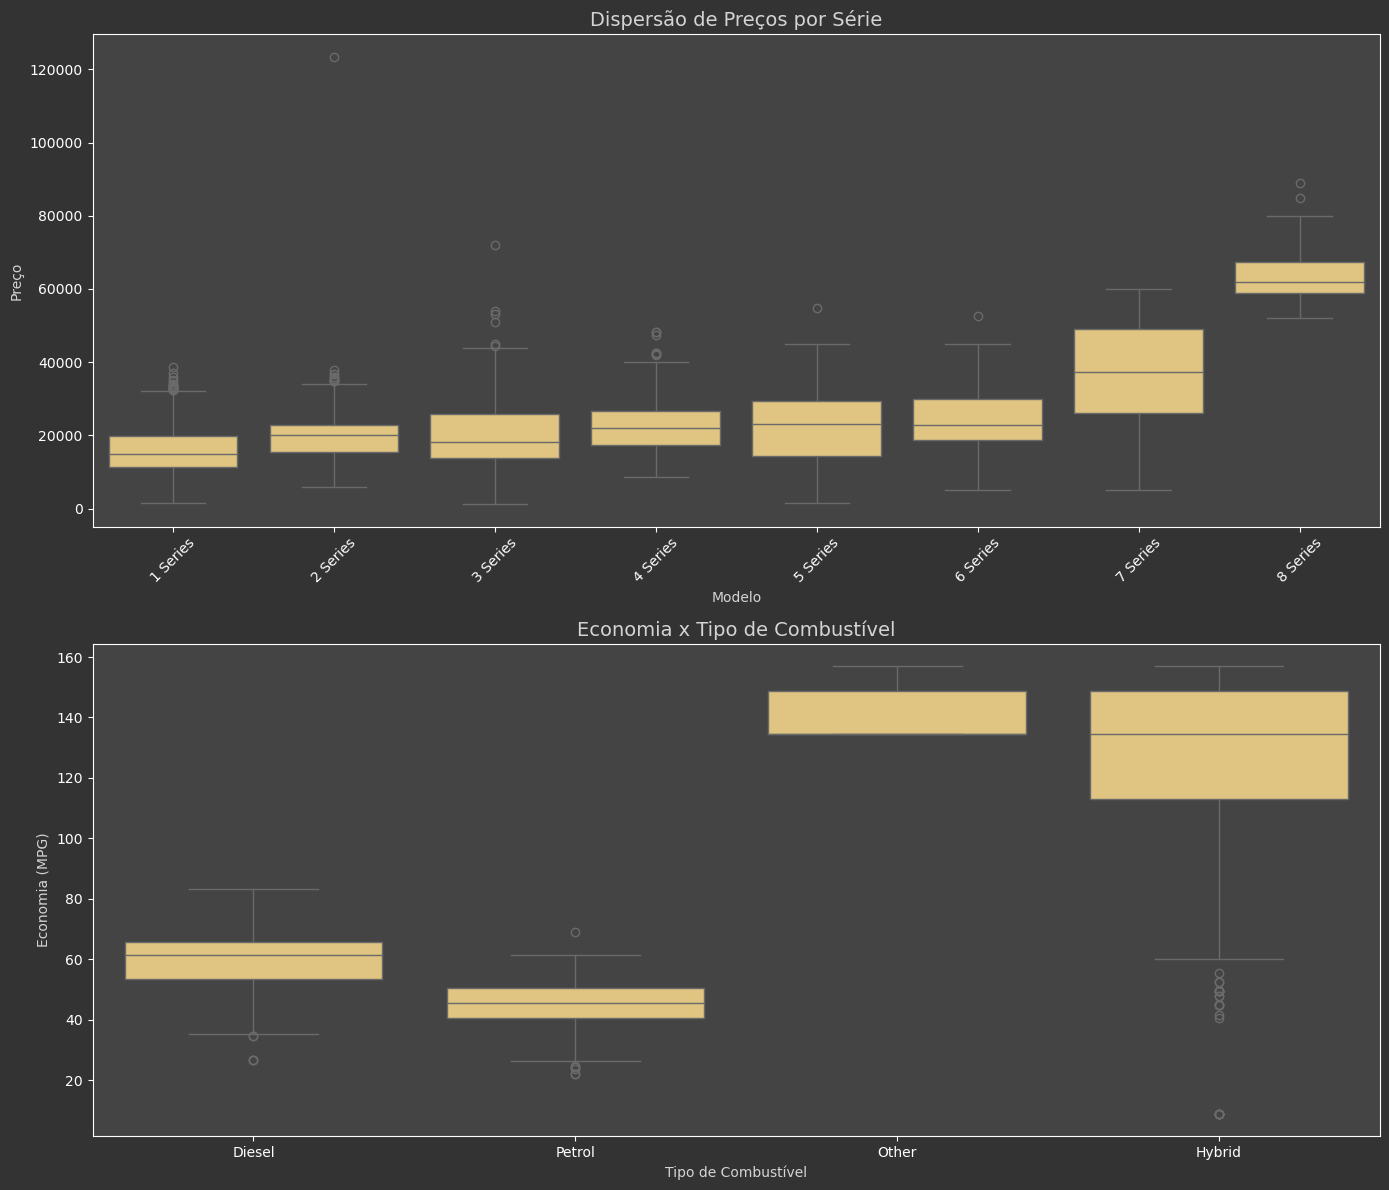

In [210]:
# Cria uma figura com espaço pra 2 gráficos
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(14, 12))

# Define a ordem 
series_order = [
    '1 Series', '2 Series', '3 Series', '4 Series',
    '5 Series', '6 Series', '7 Series', '8 Series'
]

# Preço x Modelo
sns.boxplot(
    data=df_series,
    x='modelo',
    y='preço',
    color="#f0ca71",
    order=series_order,
    ax=axes[0]
)
axes[0].set_title('Dispersão de Preços por Série', color='#d4d4d4', fontsize=14)
axes[0].set_ylabel('Preço', color='#d4d4d4')
axes[0].set_xlabel('Modelo', color='#d4d4d4')

# Rotaciona os nomes dos modelos em 45 
axes[0].tick_params(axis='x', rotation=45) 

# Economia x Combustível 
sns.boxplot(
    data=df_series,
    x='tipo de combustivel',
    y='economia',
    color="#f0ca71",
    ax=axes[1]
)
axes[1].set_title('Economia x Tipo de Combustível', color='#d4d4d4', fontsize=14)
axes[1].set_ylabel('Economia (MPG)', color='#d4d4d4')
axes[1].set_xlabel('Tipo de Combustível', color='#d4d4d4')

# Ajusta o espaçamento
plt.tight_layout()
plt.show()

### **Scatterplots:**

#### **Scatterplots de depreciação**

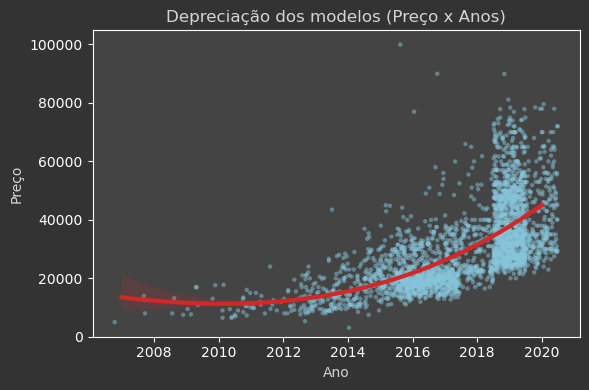

In [211]:
# Mantém apenas a grande maioria dos dados 
# para melhor visualização (trimming)
df_models_filtered = df_models[
    (df_models['ano'] >= 2007) & 
    (df_models['quilometragem'] <= 125000)
]

# Cria a figura 
fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(6, 4))

# Preço x Ano 
sns.regplot(
    data=df_models_filtered,
    x='ano',
    y='preço',
    scatter_kws={'alpha': 0.5, 's': 10, 'edgecolor': 'none', 'color': "#87c5da"},
    line_kws={'color': '#d62728', 'linewidth': 3}, 
    order=3,            
    x_jitter=0.5
)
axes.set_title('Depreciação dos modelos (Preço x Anos)', color='#d4d4d4', fontsize=12)
axes.set_ylabel('Preço', color='#d4d4d4')
axes.set_xlabel('Ano', color='#d4d4d4')
axes.set_ylim(bottom=0)

plt.tight_layout()
plt.show()

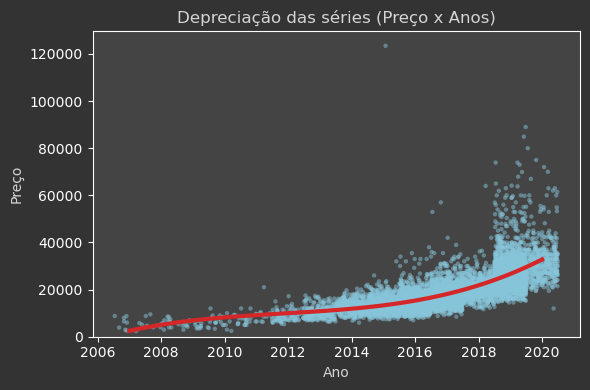

In [212]:
# Mantém apenas a grande maioria dos dados 
# para melhor visualização (trimming)
df_series_filtered = df_series[
    (df_series['ano'] >= 2007) & 
    (df_series['quilometragem'] <= 125000)
]

# Cria a figura 
fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(6, 4))

# Preço x Ano 
sns.regplot(
    data=df_series_filtered,
    x='ano',
    y='preço',
    scatter_kws={'alpha': 0.5, 's': 10, 'edgecolor': 'none', 'color': "#87c5da"},
    line_kws={'color': '#d62728', 'linewidth': 3}, 
    order=3,            
    x_jitter=0.5
)
axes.set_title('Depreciação das séries (Preço x Anos)', color='#d4d4d4', fontsize=12)
axes.set_ylabel('Preço', color='#d4d4d4')
axes.set_xlabel('Ano', color='#d4d4d4')
axes.set_ylim(bottom=0)

plt.tight_layout()
plt.show()

#### **Scatterplots de uso**

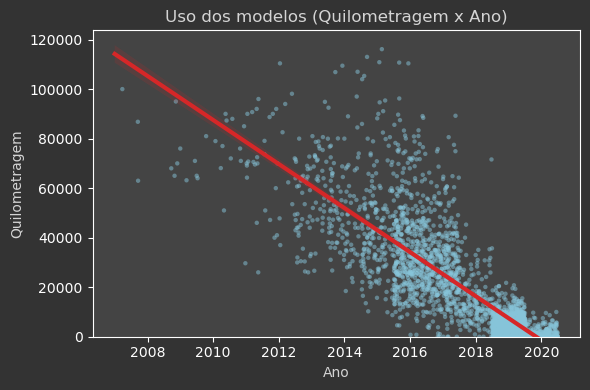

In [213]:
fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(6, 4))

# Quilometragem x Ano 
sns.regplot(
    data=df_models_filtered,
    x='ano',
    y='quilometragem',
    scatter_kws={'alpha': 0.5, 's': 10, 'edgecolor': 'none', 'color': '#87c5da'},
    line_kws={'color': '#d62728', 'linewidth': 3},
    x_jitter=0.5,
    ax=axes
)
axes.set_title('Uso dos modelos (Quilometragem x Ano)', color='#d4d4d4', fontsize=12)
axes.set_ylabel('Quilometragem', color='#d4d4d4')
axes.set_xlabel('Ano', color='#d4d4d4')
axes.set_ylim(bottom=0)

plt.tight_layout()
plt.show()


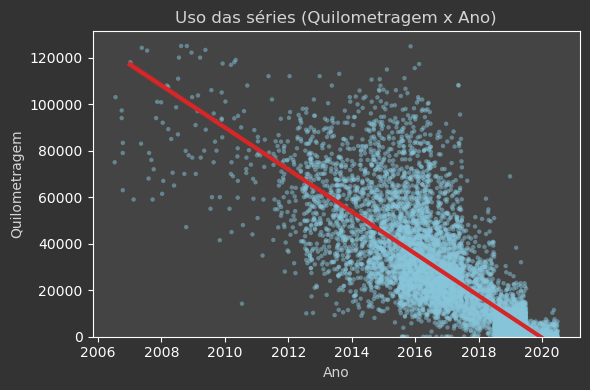

In [214]:
fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(6, 4))

# Quilometragem x Ano 
sns.regplot(
    data=df_series_filtered,
    x='ano',
    y='quilometragem',
    scatter_kws={'alpha': 0.5, 's': 10, 'edgecolor': 'none', 'color': '#87c5da'},
    line_kws={'color': '#d62728', 'linewidth': 3},
    x_jitter=0.5,
    ax=axes
)
axes.set_title('Uso das séries (Quilometragem x Ano)', color='#d4d4d4', fontsize=12)
axes.set_ylabel('Quilometragem', color='#d4d4d4')
axes.set_xlabel('Ano', color='#d4d4d4')
axes.set_ylim(bottom=0)

plt.tight_layout()
plt.show()


#### **Scatterplots de Preço por Quilometragem**

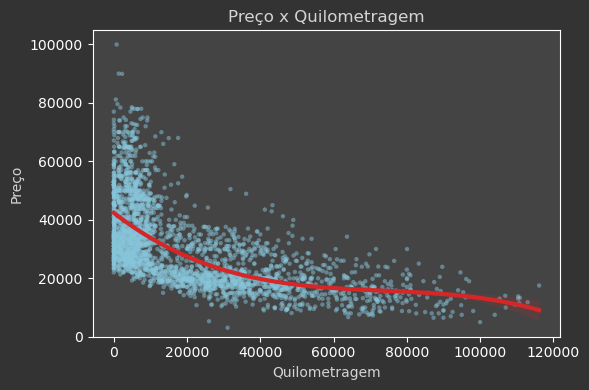

In [215]:
fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(6, 4))

# Preço x Quilometragem
sns.regplot(
    data=df_models_filtered,
    x='quilometragem',
    y='preço',
    scatter_kws={'alpha': 0.5, 's': 10, 'edgecolor': 'none', 'color': '#87c5da'},
    line_kws={'color': '#d62728', 'linewidth': 3},
    order=3,            
    ax=axes
)
axes.set_title('Preço x Quilometragem', color='#d4d4d4', fontsize=12)
axes.set_ylabel('Preço', color='#d4d4d4')
axes.set_xlabel('Quilometragem', color='#d4d4d4')
axes.set_ylim(bottom=0)

plt.tight_layout()
plt.show()

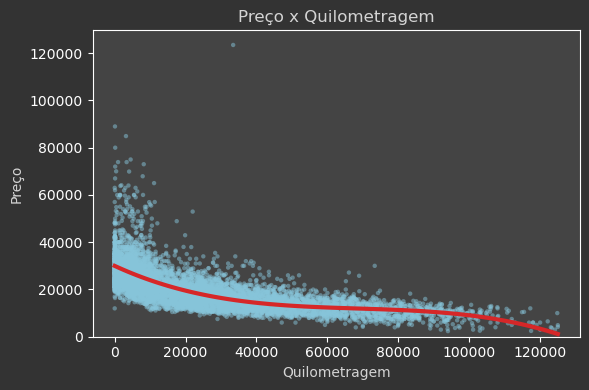

In [216]:
fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(6, 4))

# Preço x Quilometragem
sns.regplot(
    data=df_series_filtered,
    x='quilometragem',
    y='preço',
    scatter_kws={'alpha': 0.5, 's': 10, 'edgecolor': 'none', 'color': '#87c5da'},
    line_kws={'color': '#d62728', 'linewidth': 3},
    order=3,            
    ax=axes
)
axes.set_title('Preço x Quilometragem', color='#d4d4d4', fontsize=12)
axes.set_ylabel('Preço', color='#d4d4d4')
axes.set_xlabel('Quilometragem', color='#d4d4d4')
axes.set_ylim(bottom=0)

plt.tight_layout()
plt.show()

### **Realizando um teste de hipóteses:**
#### **Queremos saber se, estatísticamente, é mais econômico um carro à diesel ou à gasolina.**
#### Para isso, vamos calcular a eficiência de cada motor e depois comparar isso com os preços do diesel e da gasolina

#### **Primeiro passo: balancear as classes**
Vamos contar quantos exemplos de cada um existem nos dados e balancear pela menor quantidade. Para isso, vamos sortear o mesmo exato número dentro do maior grupo

In [217]:
# Separa os dois grupos
df_diesel = df_series[df_series['tipo de combustivel'] == 'Diesel']
df_petrol = df_series[df_series['tipo de combustivel'] == 'Petrol']

# Descobre a quantidade exata de cada classe
qtt_petrol = len(df_petrol) 
qtt_diesel = len(df_diesel) 

print(f"Quantidade de exemplos com gasolina: {qtt_petrol}")
print(f"Quantidade de exemplos com diesel: {qtt_diesel}")

# Pega a menor quantidade 
minor_qtt = min(qtt_diesel, qtt_petrol)

# Sorteia aleatoriamente a mesma quantidade de ambos os grupos
df_diesel_balanced = df_diesel.sample(n=minor_qtt, random_state=42)
df_petrol_balanced = df_petrol.sample(n=minor_qtt, random_state=42)

# Junta os dois pedaços 
df_balanced = pd.concat([df_diesel_balanced, df_petrol_balanced])

# Embaralha a ordem dos exemplos
df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"Novo total de gasolina: {len(df_balanced[df_balanced['tipo de combustivel'] == 'Petrol'])}")
print(f"Novo total de diesel:   {len(df_balanced[df_balanced['tipo de combustivel'] == 'Diesel'])}")
print(f"Total de linhas na base de estudos: {len(df_balanced)}")

Quantidade de exemplos com gasolina: 2613
Quantidade de exemplos com diesel: 5086
Novo total de gasolina: 2613
Novo total de diesel:   2613
Total de linhas na base de estudos: 5226


#### **Próximo passo: plotar o gráfico de distribuição**

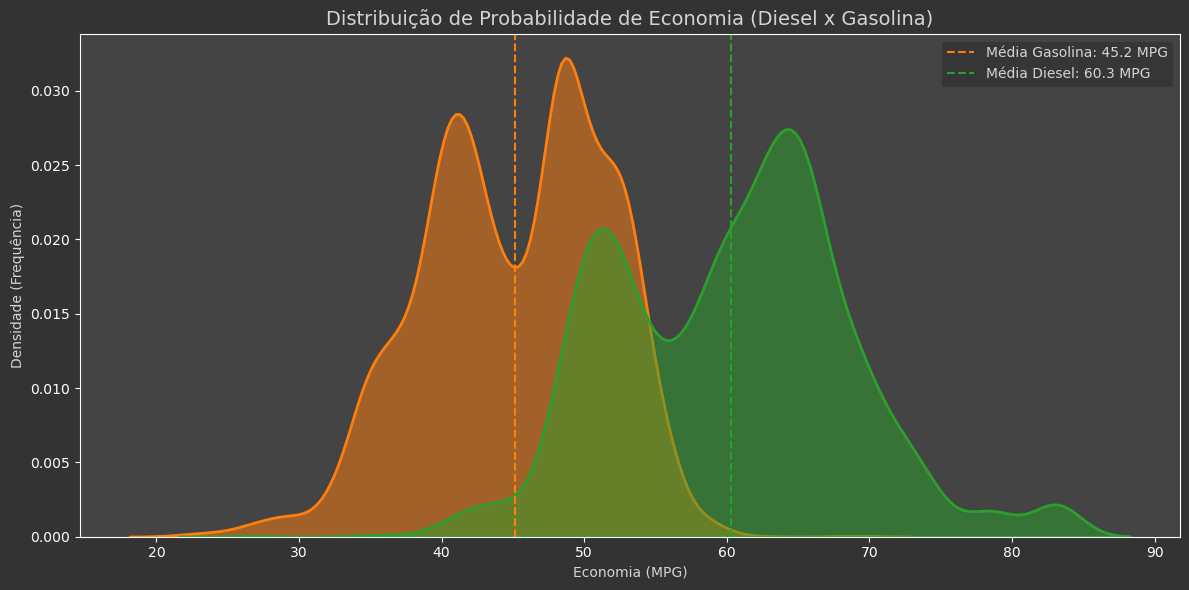

In [218]:
plt.figure(figsize=(12, 6))

# Gráfico de densidade
sns.kdeplot(
    data=df_balanced, 
    x='economia', 
    hue='tipo de combustivel', 
    fill=True,        
    palette={'Petrol': '#ff7f0e', 'Diesel': '#2ca02c'}, 
    alpha=0.5,           
    linewidth=2
)

# Títulos 
plt.title('Distribuição de Probabilidade de Economia (Diesel x Gasolina)', color='#d4d4d4', fontsize=14)
plt.xlabel('Economia (MPG)', color='#d4d4d4')
plt.ylabel('Densidade (Frequência)', color='#d4d4d4')

# Calcula as médias 
mean_petrol = df_balanced[df_balanced['tipo de combustivel'] == 'Petrol']['economia'].mean()
mean_diesel = df_balanced[df_balanced['tipo de combustivel'] == 'Diesel']['economia'].mean()

# Desenha as linhas das médias
plt.axvline(mean_petrol, color='#ff7f0e', linestyle='--', label=f'Média Gasolina: {mean_petrol:.1f} MPG')
plt.axvline(mean_diesel, color='#2ca02c', linestyle='--', label=f'Média Diesel: {mean_diesel:.1f} MPG')

# Ajustando a legenda para o fundo escuro
plt.legend(facecolor='#333333', edgecolor='#444', labelcolor='#d4d4d4')
plt.tight_layout()
plt.show()

#### **É possível ver que os dados não seguem a normalidade**, o que é esperado para dados reais. Sendo assim, **vamos realizar o teste U de Mann-Whitney**, que é não-paramétrico.

Matematicamente, ele faz: qual é a probabilidade de um carro a Diesel, escolhido ao acaso, ser mais econômico do que um carro a Gasolina, também escolhido ao acaso? 
Para isso, ele junta todos os carros em uma grande fila e os ranqueia

In [219]:
# Isola as variáveis
economia_diesel = df_balanced[df_balanced['tipo de combustivel'] == 'Diesel']['economia']
economia_gasolina = df_balanced[df_balanced['tipo de combustivel'] == 'Petrol']['economia']

# Executa o Teste U de Mann-Whitney
u_stat, p_valor = stats.mannwhitneyu(economia_diesel, economia_gasolina, alternative='greater')

# Imprime os resultados 
print("Resultado do teste U de Mann-Whitney")
print(f"Estatística U: {u_stat}")
print(f"P-Valor: {p_valor}")

# Nível de confiança de 95%
significance = 0.05 

print("\nConclusão Estatística:")
if p_valor < significance:
    print("Rejeitamos a Hipótese Nula (H0)")
    print("Está provado com significância estatística que os motores a Diesel são mais eficientes que os a Gasolina")
else:
    print("Falhamos em rejeitar a Hipótese Nula (H0)")
    print("A diferença visual pode ser obra do acaso. Não podemos afirmar que motores a Diesel são superior")

Resultado do teste U de Mann-Whitney
Estatística U: 6313299.5
P-Valor: 0.0

Conclusão Estatística:
Rejeitamos a Hipótese Nula (H0)
Está provado com significância estatística que os motores a Diesel são mais eficientes que os a Gasolina


#### Para finalizar, vamos usar os dados de preço por galão dos combustíveis e calcular qual deles é mais vantajoso

In [220]:
# Calcula a idade do carro (Data da coleta: 2020)
df_balanced['idade'] = 2020 - df_balanced['ano']

# Se o carro é de 2020 (idade = 0), arredonda para 1 ano de uso
df_balanced['idade'] = df_balanced['idade'].replace(0, 1)

# Calcula quantas milhas cada carro rodou por ano
df_balanced['milhas_por_ano'] = df_balanced['quilometragem'] / df_balanced['idade']

# Descobrindo a média real do mercado 
anual_miles = df_balanced['milhas_por_ano'].mean()

print(f"Os donos de BMW rodam em média {anual_miles:,.0f} milhas por ano\n")

# Preços por galão
petrol_price = 6.25
diesel_price = 6.86 

# Eficiências extraídas do teste
mpg_petrol = df_balanced[df_balanced['tipo de combustivel'] == 'Petrol']['economia'].mean()
mpg_diesel = df_balanced[df_balanced['tipo de combustivel'] == 'Diesel']['economia'].mean()

# Fórmula de custo
petrol_anual_cost = (anual_miles / mpg_petrol) * petrol_price
diesel_anual_cost = (anual_miles / mpg_diesel) * diesel_price
dif = petrol_anual_cost - diesel_anual_cost

print(f"Eficiência da gasolina: {mpg_petrol:.1f} MPG")
print(f"Eficiência do diesel: {mpg_diesel:.1f} MPG")

if dif > 0:
    print(f"O diesel é mais vantajoso")
    print(f"Economia anual para o cliente: {dif:,.2f}")
elif dif< 0:
    print(f"A gasolina é mais vantajosa")
    print(f"Economia anual para o cliente: {abs(dif):,.2f}")

Os donos de BMW rodam em média 7,394 milhas por ano

Eficiência da gasolina: 45.2 MPG
Eficiência do diesel: 60.3 MPG
O diesel é mais vantajoso
Economia anual para o cliente: 182.45


# Apresentação do Eixo 2

## Imports

## Pré-processamento dos dados